# ComfyUI 이미지 생성 서비스 — 설계와 구현

> 로컬 ComfyUI를 **FastAPI 게이트웨이**로 감싸, 사용자가 프롬프트를 넣으면 이미지를 생성해 돌려주는 서비스.

설명 위주로 채워질 내용임
---


## 1. 개요

사용자가 텍스트 프롬프트를 입력하면, 로컬에 떠 있는 ComfyUI를 통해 이미지를 생성해서 돌려주는 서비스. 
프론트엔드(Streamlit)에서 프롬프트를 받아 백엔드(FastAPI)로 보내고, 
백엔드가 ComfyUI에 그림 생성을 시킨 뒤 완성된 PNG를 사용자에게 반환한다.

보통의 모델 서빙은 모델 가중치를 서버 프로세스 안에 직접 올린다
하지만 이미지 생성 모델은 무겁고, 이미 ComfyUI라는 완성된 추론 엔진이 로컬에 돌고 있다. 
그래서 모델을 다시 올리는 대신, **이미 떠 있는 ComfyUI(:8000)에 추론을 위임하고 
FastAPI는 그 앞단 게이트웨이 역할만** 하도록 설계했다. 
FastAPI는 인증·검증·에러처리·응답변환을 맡고, 실제 그림 생성은 ComfyUI가 한다.

Day 5에서 만든 `FastAPI + Streamlit` 뼈대를 거의 그대로 가져왔다. 바뀐 것은 백엔드 추론부 하나
모델을 로드해 `predict()`하는 대신, ComfyUI에 HTTP로 작업을 큐잉하고 결과를 폴링해 받아온다.


## 2. 시스템 구조

**3계층 구조.** 사용자 입력은 세 계층을 거쳐 이미지로 돌아온다.

```
[사용자]
   |  프롬프트 입력
   v
[Streamlit 프론트엔드  :8501]          app.py
   |  POST /generate  (X-API-Key 헤더 + JSON 본문)
   v
[FastAPI 게이트웨이    :8001]          comfy_gateway.py
   |  - 인증        auth.py            (API Key 검증)
   |  - 입력 검증   GenerateRequest    (Pydantic, comfy_gateway.py 안)
   |  - 추론 위임   build_workflow -> queue_prompt -> wait_for_result
   |       /prompt -> /history(폴링) -> /view
   v
[ComfyUI  :8000]                       (ComfyUI 데스크톱 앱, GPU 추론)
   |  워크플로우 실행 -> PNG 생성
   v
[PNG 바이너리]  <- 게이트웨이가 image/png 로 그대로 반환
```

**요청 흐름.**
1. 사용자가 Streamlit에서 프롬프트를 입력하고 버튼을 누른다.
2. Streamlit이 API Key 헤더와 함께 게이트웨이의 `POST /generate`를 호출한다.
3. 게이트웨이가 API Key를 검증하고(없거나 틀리면 401), Pydantic으로 입력을 검증한다(틀리면 422).
4. 검증을 통과하면 워크플로우에 프롬프트를 주입해 ComfyUI에 큐잉하고, 완성될 때까지 `/history`를 폴링한다.
5. 완성된 이미지를 `/view`로 받아 `image/png` 바이너리로 사용자에게 반환한다.

**파일 구조.** 실제 작업 폴더는 평탄한 단일 폴더다 (app/ 같은 하위 패키지로 나누지 않음).

```
새 폴더 (4)/
- comfy_gateway.py     # FastAPI 게이트웨이 (인증/검증/프롬프트 주입/큐잉/폴링/엔드포인트)
- auth.py              # API Key 인증 (Day 6 재사용)
- app.py               # Streamlit 프론트엔드
- workflow_api.json    # ComfyUI 워크플로우 (API Format export)
- start_demo.bat       # 게이트웨이+streamlit+ngrok 일괄 실행
- stop_demo.bat        # 일괄 종료
```


## 3. 설계 결정

서비스를 짜면서 내린 핵심 결정들과 그 이유다.

**게이트웨이 vs 인프로세스 로드.** 모델을 FastAPI 프로세스 안에 직접 올리면 메모리를 크게 점유하고 생명주기 관리가 까다롭다. 반면 ComfyUI는 이미 그래프 기반 워크플로우 엔진으로 완성돼 있어, 거기에 위임하면 게이트웨이는 가볍게 유지된다. 대신 네트워크 호출과 폴링이라는 복잡성이 생긴다 — 실무의 모델 서버 분리 패턴과 같은 트레이드오프다.

>> 모델을 서버에 올리지 않고 로컬에서 직접 comfyui 를 구동했다는 소리다. 
>> 이미지 생성모델이 무겁고 의존성이 많이 있어서 사실 이 구조를 서버에 올리기가 여간 쉬운일은 아니기 때문에 이건 처음부터 어느정도 결정된 일이었다. 덕분에 작업중에는 대기열이 생기는 비동기 작업과는 거리가 먼 서비스 제공을 하게 된다는 점이 약점이다. 


**PNG 바이너리 vs JSON.** Day 5 주택가격은 숫자 하나를 JSON으로 반환했다(`{"price": ...}`). 이미지 생성은 결과가 PNG라서 JSON에 담기 부적절하다. 그래서 `/generate`는 Pydantic 응답 모델 없이 `Response(media_type="image/png")`로 바이너리를 그대로 반환한다. 입력 검증 스키마(`GenerateRequest`)만 두고 출력 스키마는 두지 않은 이유다.

>>결과는 json반환이 아니라 이미지파일을 반환해주는것을 말한다. 
>> PNG파일을 반환해야하기 때문에 이 파일을 통째로 응답으로 보낸다. 그래서 입력같은 경우에는 검증 틀이 있지만 출력에는 정해진 틀이 존재하지 않는다 


**워크플로우 노드 주입 (54 / 11 / 2).** ComfyUI 워크플로우를 API Format으로 내보내면, 각 노드가 번호 키를 가진 JSON이 된다. 매 요청마다 이 템플릿을 복사한 뒤 세 노드만 덮어쓴다.

| 노드 | 종류 | 덮어쓰는 값 | 이유 |
| --- | --- | --- | --- |
| `54` | Text Prompt (JPS) | `inputs.text` | 사용자 프롬프트 주입 |
| `11` | KSampler (Efficient) | `inputs.seed` | 매 요청 랜덤 → 같은 프롬프트도 다른 그림 |
| `2` | EmptyLatentImage | `inputs.batch_size = 1` | 데모 속도 위해 1장만 생성 |

**시드/배치 처리.** 시드를 고정하면 같은 프롬프트가 늘 같은 그림을 내므로, 서버에서 매번 랜덤 시드를 넣는다. 배치는 1로 고정해 응답을 빠르게 한다.

**동기 폴링 (옵션 A).** ComfyUI는 작업을 큐에 넣고 비동기로 처리한다. 가장 단순한 방식으로, `/prompt`로 큐잉한 뒤 `/history/{id}`를 일정 간격으로 폴링해 완성되면 결과를 가져온다. 요청이 끝날 때까지 한 슬롯을 점유한다는 한계가 있지만, 데모로는 충분하고 흐름이 직관적이다.


>>comfyui에서 존재하는 세팅은 건들지 않고 사용자는 입력을 통해서 프롬프트를 변경할수 있게 했다. 매 요청마다 3개의 노드인 54번은 유저 프롬프트, 11번은 랜덤시드, 2번은 배치사이즈를 결정한다. 

>> 동기 플링 방식이 약점 
GPU를 늘려서 ComfyUI 인스턴스를 여러 개 돌리면 → 동시에 여러 장을 병렬 생성할 수 있다. 그리고 그 여러 인스턴스를 재현·관리하려면 결국 도커(컨테이너)가 필요하다.

추가로 외부 배포를 한번 해보기 위해서 ngrok 임시 터널로 공개 url을 만들어 본다. 
플론트앤드만 터널로 노출하고 게이트웨이와 comfyui 는 로컬로 비공개로 둔다. 
프론트를 통해 백엔드로 연결되는 구조지 않을까 싶다. 

우선 ngrok에서 api키를 발급받아 터널을 열고 나면  url을 통해 누구든지 접근할수가 있는 구조가 되어있다. api키가 존재하긴 하지만 
자동으로 입력이 되기 때문에 보안상으로는 상당히 취약하게 만들어져있다. 



## 4. 코드 — 파일별 설명

세 개의 파일로 구성된다. 의존 순서대로 본다: `auth.py` (인증) -> `comfy_gateway.py` (게이트웨이 본체) -> `app.py` (프론트엔드).

- **`auth.py`** — API Key 인증. Day 6에서 만든 모듈을 그대로 재사용.
- **`comfy_gateway.py`** — 서비스의 본체. 입력 스키마(`GenerateRequest`), 워크플로우 주입, ComfyUI 큐잉/폴링, 엔드포인트(`/generate`, `/health`)가 한 파일에 모여 있다.
- **`app.py`** — Streamlit UI.

> 참고: Day 8 템플릿은 `app/auth.py / schemas.py / model_service.py / main.py` 처럼 파일을 나누도록 안내하지만, 이 프로젝트는 게이트웨이 한 덩어리가 작아서 `comfy_gateway.py` 하나로 합쳤다. 역할(인증/검증/위임/엔드포인트)은 그대로 분리돼 있고 파일만 합친 것이다.


### 4.1 `auth.py` — API Key 인증

Day 6에서 만든 인증 모듈을 그대로 재사용한다. 헤더 `X-API-Key`를 검사해서, 없으면 401, 등록되지 않은 키면 401을 던지고, 유효하면 그 키에 매핑된 사용자 이름을 반환한다. FastAPI의 `Depends`로 엔드포인트에 끼우면, 인증이 통과해야만 핸들러가 실행된다.


In [ ]:
from fastapi import HTTPException, Header

VALID_API_KEYS = {
    "test-key-001": "사용자A",
    "test-key-002": "사용자B",
}


async def verify_api_key(x_api_key: str = Header(None)) -> str:
    if x_api_key is None:
        raise HTTPException(
            status_code=401,
            detail="API Key가 필요합니다. X-API-Key 헤더를 포함해 주세요.",
        )
    if x_api_key not in VALID_API_KEYS:
        raise HTTPException(
            status_code=401,
            detail="유효하지 않은 API Key입니다.",
        )
    return VALID_API_KEYS[x_api_key]


### 4.2 comfy_gateway.py — FastAPI 게이트웨이

이 서비스의 본체다. 일반적인 서빙의 "모델 로드 + predict" 자리를, "워크플로우 템플릿 로드 + ComfyUI에 위임"으로 바꾼 것이 핵심이다.

- 입력 스키마 (`GenerateRequest`) — `prompt: str`을 받고 `Field(min_length=1, max_length=2000)`로 검증한다. 빈 입력/과도한 길이는 Pydantic이 422로 막는다. 출력은 PNG 바이너리라 응답 스키마는 두지 않는다.

- 워크플로우 주입 (`build_workflow`) — 시작 시 한 번 읽어둔 `workflow_api.json` 템플릿을 매 요청마다 `deepcopy`한 뒤 세 노드만 덮어쓴다: 노드 54(사용자 프롬프트), 노드 11(랜덤 시드), 노드 2(batch_size=1).

- 큐잉/폴링 (`queue_prompt` / `wait_for_result`) — ComfyUI에 `/prompt`로 작업을 큐잉하고 `prompt_id`를 받은 뒤, `/history/{id}`를 0.5초 간격으로 폴링해 완성되면 결과를 꺼낸다. `httpx.AsyncClient`로 비동기 HTTP 호출을 쓴다.

- 엔드포인트 — `POST /generate` (인증 `Depends(verify_api_key)` 적용, 완성된 PNG를 `image/png`로 반환), `GET /health` (게이트웨이 + ComfyUI 상태 확인).

왜 `run_in_executor`를 안 쓰나. Day 1~7에서 배운 패턴은 "블로킹 CPU 추론을 `run_in_executor`로 스레드에 떼어 이벤트 루프를 막지 않는" 것이다. 그런데 이 게이트웨이는 모델을 직접 돌리지 않고 ComfyUI를 `httpx`로 호출하는 **I/O 바운드** 작업이다. `await`로 이미 논블로킹이라 별도 executor가 필요 없다. (업스트림 주소는 환경변수 `COMFY_URL`로 주입하며, 데모에서는 `http://127.0.0.1:8000`을 쓴다.)
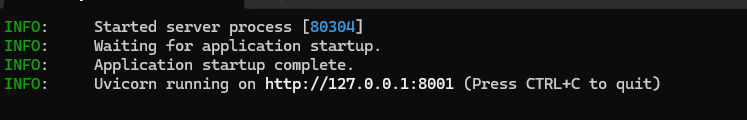

In [ ]:
import asyncio
import copy
import json
import os
import random
import uuid
from pathlib import Path

import httpx
from fastapi import FastAPI, HTTPException, Depends
from fastapi.responses import Response
from pydantic import BaseModel, Field

from auth import verify_api_key

# --- 설정 (환경변수로 덮어쓸 수 있음) ---------------------------------------
COMFY_URL = os.environ.get("COMFY_URL", "http://127.0.0.1:8188")  # ComfyUI 주소
WORKFLOW_PATH = Path(__file__).parent / "workflow_api.json"
POLL_INTERVAL = 0.5      # 초. history 폴링 간격
TIMEOUT_SECONDS = 180    # 한 요청 최대 대기 시간

PROMPT_NODE = "54"       # 🌄 유저 입력이 들어갈 빈 Text Prompt 노드
SEED_NODE = "11"         # KSampler (Efficient)
LATENT_NODE = "2"        # EmptyLatentImage (batch_size)
# ----------------------------------------------------------------------------

app = FastAPI(title="ComfyUI Gateway")

# 워크플로우 템플릿은 시작할 때 한 번만 읽어둔다 (요청마다 deepcopy해서 사용)
WORKFLOW_TEMPLATE = json.loads(WORKFLOW_PATH.read_text(encoding="utf-8"))


class GenerateRequest(BaseModel):
    prompt: str = Field(..., min_length=1, max_length=2000,
                        description="이미지 생성 프롬프트")


def build_workflow(prompt: str) -> dict:
    """템플릿을 복사해서 이번 요청용 워크플로우를 만든다."""
    wf = copy.deepcopy(WORKFLOW_TEMPLATE)
    wf[PROMPT_NODE]["inputs"]["text"] = prompt + ", "                # 1) 유저 입력 주입(+뒤 태그와 콤마 구분)
    wf[SEED_NODE]["inputs"]["seed"] = random.randint(0, 2**63 - 1)   # 2) 시드 랜덤
    wf[LATENT_NODE]["inputs"]["batch_size"] = 1                      # 3) 1장
    return wf


async def queue_prompt(client: httpx.AsyncClient, workflow: dict, client_id: str) -> str:
    """ComfyUI 큐에 워크플로우를 넣고 prompt_id를 받는다."""
    r = await client.post(
        f"{COMFY_URL}/prompt",
        json={"prompt": workflow, "client_id": client_id},
    )
    if r.status_code != 200:
        # ComfyUI는 검증 실패 시 어느 노드가 왜 틀렸는지 본문에 담아 보낸다
        raise HTTPException(status_code=502, detail=f"ComfyUI 큐잉 실패: {r.text}")
    return r.json()["prompt_id"]


async def wait_for_result(client: httpx.AsyncClient, prompt_id: str) -> dict:
    """history에 prompt_id가 나타날 때까지(=완성될 때까지) 폴링."""
    waited = 0.0
    while waited < TIMEOUT_SECONDS:
        r = await client.get(f"{COMFY_URL}/history/{prompt_id}")
        history = r.json()
        if prompt_id in history:
            return history[prompt_id]
        await asyncio.sleep(POLL_INTERVAL)
        waited += POLL_INTERVAL
    raise HTTPException(status_code=504, detail="생성 시간 초과")


def find_image_ref(history_entry: dict) -> dict | None:
    """완성된 history 항목에서 첫 번째 이미지 참조(filename/subfolder/type)를 찾는다."""
    for node_output in history_entry.get("outputs", {}).values():
        images = node_output.get("images")
        if images:
            return images[0]
    return None


@app.post("/generate")
async def generate(req: GenerateRequest, user: str = Depends(verify_api_key)):
    if not req.prompt.strip():
        raise HTTPException(status_code=400, detail="프롬프트가 비어있어")

    client_id = str(uuid.uuid4())
    workflow = build_workflow(req.prompt)

    async with httpx.AsyncClient(timeout=TIMEOUT_SECONDS + 10) as client:
        prompt_id = await queue_prompt(client, workflow, client_id)
        history_entry = await wait_for_result(client, prompt_id)

        image_ref = find_image_ref(history_entry)
        if image_ref is None:
            status = history_entry.get("status", {})
            raise HTTPException(status_code=500, detail=f"이미지를 못 찾았어. status={status}")

        img = await client.get(
            f"{COMFY_URL}/view",
            params={
                "filename": image_ref["filename"],
                "subfolder": image_ref.get("subfolder", ""),
                "type": image_ref.get("type", "output"),
            },
        )
        return Response(content=img.content, media_type="image/png")


@app.get("/health")
async def health():
    """게이트웨이와 ComfyUI가 살아있는지 빠르게 확인."""
    async with httpx.AsyncClient(timeout=5) as client:
        try:
            r = await client.get(f"{COMFY_URL}/system_stats")
            comfy = "ok" if r.status_code == 200 else "unreachable"
        except httpx.HTTPError:
            comfy = "unreachable"
    return {"gateway": "ok", "comfyui": comfy}


### 4.3 `app.py` — Streamlit UI

사용자가 만지는 화면이다. 사이드바에서 API Key를 입력받고, 프롬프트를 입력받아 생성 버튼을 누르면 게이트웨이의 `/generate`를 호출한다. 응답이 200이면 받은 PNG 바이트를 `st.image`로 바로 띄우고, 그 외 상태 코드면 에러 메시지를 보여준다. 
게이트웨이가 안 떠 있으면 연결 오류도 따로 안내한다.
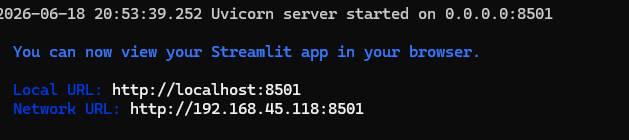

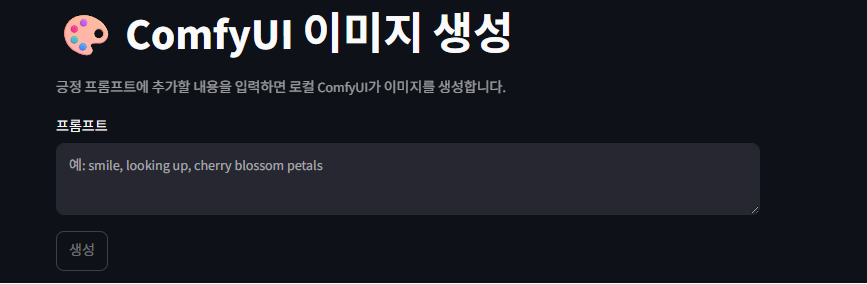

In [ ]:
import os

import requests
import streamlit as st

GATEWAY_URL = os.environ.get("GATEWAY_URL", "http://127.0.0.1:8001")

st.set_page_config(page_title="AI 이미지 생성", page_icon="🎨")
st.title("🎨 ComfyUI 이미지 생성")
st.caption("긍정 프롬프트에 추가할 내용을 입력하면 로컬 ComfyUI가 이미지를 생성합니다.")

# 사이드바: API Key 입력 (게이트웨이 인증용)
with st.sidebar:
    api_key = st.text_input(
        "API Key",
        value="test-key-001",
        type="password",
        help="게이트웨이 접근에 필요한 키입니다. (예: test-key-001)",
    )

prompt = st.text_area(
    "프롬프트",
    placeholder="예: smile, looking up, cherry blossom petals",
    height=100,
)

if st.button("생성", type="primary", disabled=not prompt.strip()):
    with st.spinner("생성 중... (20스텝이라 몇 초 걸려요)"):
        try:
            resp = requests.post(
                f"{GATEWAY_URL}/generate",
                json={"prompt": prompt},
                headers={"X-API-Key": api_key},
                timeout=200,
            )
            if resp.status_code == 200:
                st.image(resp.content, caption=prompt, use_container_width=True)
            else:
                st.error(f"생성 실패 ({resp.status_code}): {resp.text}")
        except requests.exceptions.RequestException as e:
            st.error(f"게이트웨이 연결 실패: {e}")


## 5. 실행 흐름 (설명)


1) ComfyUI 켜기 (:8000). ComfyUI 데스크톱 앱을 실행. 게이트웨이가 위임할 업스트림 추론 엔진이며, 데스크톱 앱은 기본으로 8000번 포트를 쓴다.

2) 게이트웨이 + 프론트 + 터널 일괄 실행.** `start_demo.bat`를 더블클릭하면 세 프로세스가 각각 별도 창으로 뜬다.
- 게이트웨이: `set COMFY_URL=http://127.0.0.1:8000` 후 `python -m uvicorn comfy_gateway:app --port 8001`
- 프론트엔드: `python -m streamlit run app.py` (:8501)
- 외부 노출: `ngrok http 8501` (프론트만 공개, 게이트웨이/ComfyUI는 로컬에 둔다)

종료는 `stop_demo.bat`. (ComfyUI 데스크톱 앱은 건드리지 않는다.)

3) 요청이 도는 경로.
```
Streamlit 입력
  -> POST /generate (X-API-Key 헤더)
    -> verify_api_key  (401 if 무/오류 키)
    -> GenerateRequest (422 if 검증 실패: 빈 값/길이 초과)
    -> build_workflow  (노드 54/11/2 주입)
    -> ComfyUI /prompt  (큐잉)
    -> /history 폴링     (완성 대기, httpx async)
    -> /view             (PNG 회수)
    -> Response(image/png)
  -> st.image 로 표시
```

4) 테스트 방법.
- Swagger UI: `http://localhost:8001/docs` 에서 `/generate` 직접 호출
- 인증 확인: API Key 없이 요청 -> **401**, 틀린 키 -> **401**, 올바른 키 -> **200 + 이미지**
- 잘못된 입력(빈 프롬프트 등) -> **422**
- Streamlit: 사이드바에 API Key 입력 후 프롬프트 -> 이미지 표시
- 외부 접속: ngrok 창에 뜬 공개 URL(매 실행마다 바뀜)로 친구가 접속해 테스트


## 6. 마무리 — 한계와 다음 단계

현재 구조의 한계.
- 동기 폴링 — 한 요청이 완성될 때까지 요청 연결을 점유한다(async 단일 큐). 동시 사용자가 늘면 큐가 밀린다. 실무라면 작업 큐(Celery/RQ)나 웹소켓 알림으로 바꿀 지점이다.
- 단일 업스트림 — ComfyUI 인스턴스 하나에 의존한다. 죽으면 서비스 전체가 503.
- GPU 의존 — 이미지 생성은 GPU가 필수라, 아무 데서나 못 띄운다.
- 노드 ID 하드코딩 — 워크플로우 구조(54·11·2)에 코드가 묶여 있다. 워크플로우를 바꾸면 상수도 같이 고쳐야 한다.

다음 단계: 컨테이너. 이 프로젝트에서 제일 어려웠던 건 코드가 아니라 환경 정합성이었다. ComfyUI 포터블 실행, 포트 충돌, 의존성 버전, 세 프로세스를 동시에 띄우고 포트를 맞추는 일. 이걸 한 번 정의하면 재현되게 만드는 게 컨테이너(Docker)이고, 여러 서비스를 함께 정의·실행하는 게 Docker Compose다. 다만 ComfyUI는 GPU 추론이라 컨테이너화에 GPU 패스스루(nvidia-container-toolkit) 설정이 한 겹 더 필요하다 — 순수 파이썬인 게이트웨이·프론트엔드보다 까다로운 부분이다.

근본원인은 GPU1개가 1장씩 그린다는 점인데 이를 해결하려면 결국 여러 인스턴스를 띄워 요청에 따라 병렬로 생산해야하는데 지금 환경에서는 조금 어려운것 같다. 또 프로젝트 진행 중에서 환경이 계속 바뀌어서 포트를 맞추지 못하는 에러가 많이 발생했는데 아마 도커를 쓰면 이게 좀 해결이 되지 않을까? 
